In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import pandas as pd

In [24]:
from sklearn.datasets import make_moons
X, y = make_moons(
    n_samples=600,
    random_state=42,
    noise=0.25
)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

pre-Pruning dataset

In [26]:
depths_list = list(range(1, 15))
test_acc_pre = []
train_acc_pre = []

for d in depths_list:
    model = DecisionTreeClassifier(
        max_depth=d,
        random_state=42,
        min_samples_leaf=5
    )
    model.fit(X_train, y_train)
    train_acc_pre.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc_pre.append(accuracy_score(y_test, model.predict(X_test)))

In [27]:
test_acc_pre

[0.85,
 0.9055555555555556,
 0.9055555555555556,
 0.9055555555555556,
 0.9222222222222223,
 0.9166666666666666,
 0.9166666666666666,
 0.9166666666666666,
 0.9166666666666666,
 0.9166666666666666,
 0.9166666666666666,
 0.9166666666666666,
 0.9166666666666666,
 0.9166666666666666]

post _PRUNING

In [28]:
fulltree=DecisionTreeClassifier(
    random_state=42
)
fulltree.fit(X_train,y_train)
path=fulltree.cost_complexity_pruning_path(X_train,y_train)
ccp_alpha=path.ccp_alphas
test_acc_post=[]
train_acc_post=[]

for alpha in ccp_alpha:
    model1=DecisionTreeClassifier(
        ccp_alpha=alpha,
        random_state=42
    )
    model1.fit(X_train,y_train)
    train_acc_post.append(accuracy_score(y_train, model1.predict(X_train)))
    test_acc_post.append(accuracy_score(y_test, model1.predict(X_test)))

In [29]:
test_acc_post

[0.8777777777777778,
 0.8777777777777778,
 0.8833333333333333,
 0.8833333333333333,
 0.8888888888888888,
 0.9277777777777778,
 0.9222222222222223,
 0.9166666666666666,
 0.9222222222222223,
 0.9222222222222223,
 0.9055555555555556,
 0.9055555555555556,
 0.8777777777777778,
 0.85,
 0.5]

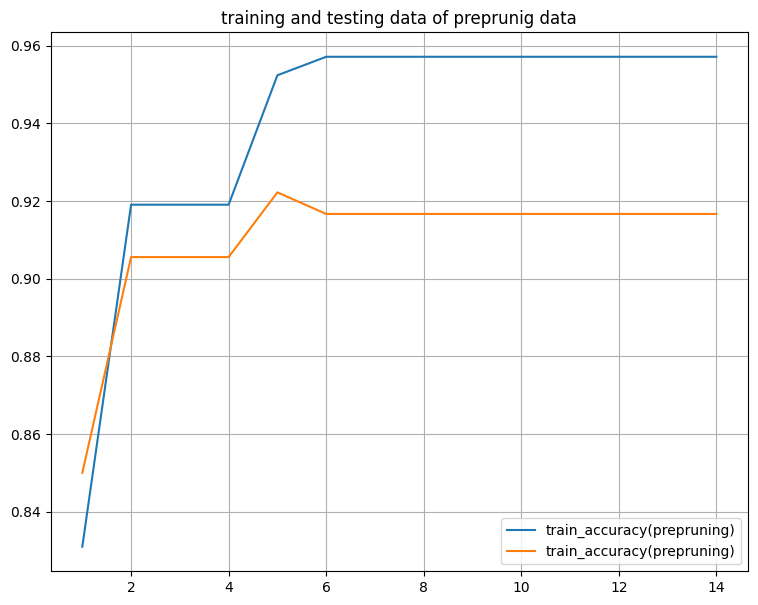

In [30]:
plt.figure(figsize=(9,7))
plt.plot(depths_list,train_acc_pre,label='train_accuracy(prepruning)')
plt.plot(depths_list,test_acc_pre,label='train_accuracy(prepruning)')
plt.title("training and testing data of preprunig data")
plt.legend()
plt.grid(True)
plt.show()


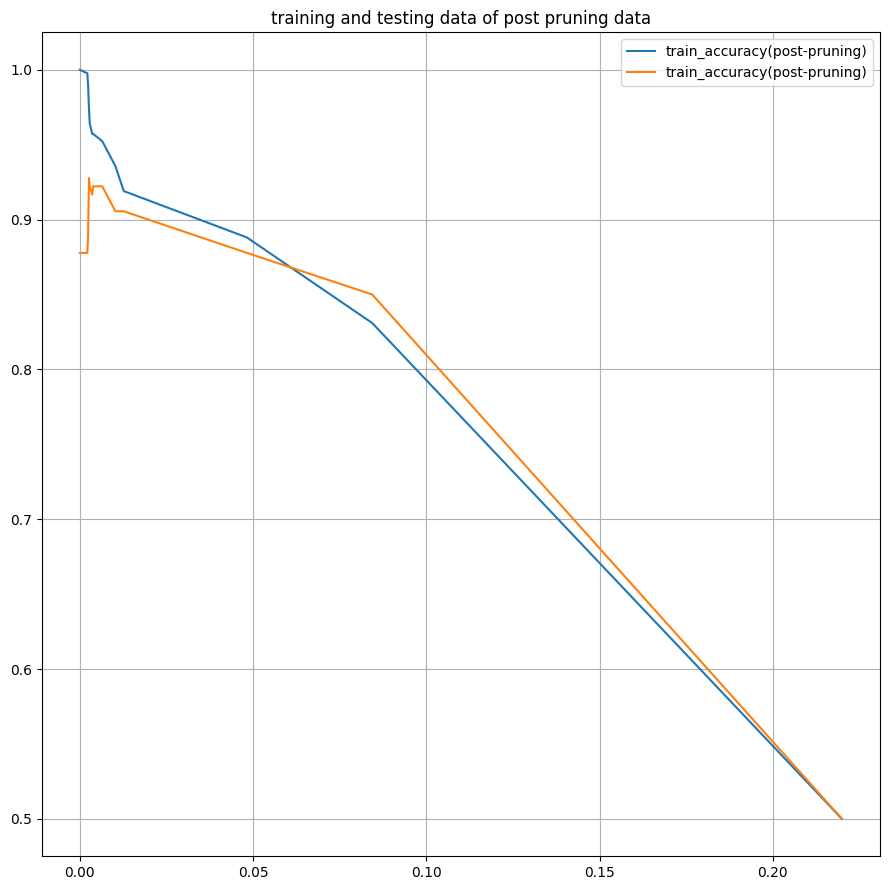

In [33]:
plt.figure(figsize=(9,9))
plt.plot(ccp_alpha,train_acc_post,label='train_accuracy(post-pruning)')
plt.plot(ccp_alpha,test_acc_post,label='train_accuracy(post-pruning)')
plt.title("training and testing data of post pruning data")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [38]:
best_path=ccp_alpha[np.argmax(test_acc_post)]
print(f"the best depth is:{best_path:.6f}")

the best depth is:0.002642


In [39]:
best_path=depths_list[np.argmax(test_acc_pre)]
print(f"the best scores is{best_path}")

the best scores is5
